# Lesson 03: Market data and price aggregation
**Level:** intermediate · **Before this:** Lessons 01–02 help, but every term is explained again here.

> **How to read this notebook:** you don't need to understand the Python. Read the 🔧 line above each grey code
> box (what the code does, in plain words), then the output and the explanation under it.

### What this lesson is about
Each of our three LPs (liquidity providers: the banks/market makers we get prices from) sends us its own prices,
about once a second per symbol. The clients don't see three prices. They see **one**: the best of the three. The
bridge's job of combining them is called **aggregation**, and the combined price list is the **aggregated order
book**.

**Example:** at one moment the three LPs quote EURUSD like this:

| LP | Bid (price the LP **buys** at = price a client can **sell** at) | Ask/Offer (price the LP **sells** at = price a client can **buy** at) |
|---|---|---|
| LP_A | 1.16248 | 1.16254 |
| LP_B | **1.16249** | 1.16255 |
| LP_C | 1.16247 | **1.16252** |

The bridge takes the **highest bid** (1.16249 from LP_B) and the **lowest ask** (1.16252 from LP_C). The client sees
1.16249 / 1.16252, a spread of 0.3 pips, better than any single LP. That's the whole point of having several LPs.

### Words used in this lesson
| Word | Meaning |
|---|---|
| **Quote** | One price update from an LP: bid and ask (plus sizes). In FIX it arrives as a `35=W` message (MsgType = MarketDataSnapshotFullRefresh) |
| **Bid / Ask** | Bid = the price the LP will buy at. Ask (also "offer") = the price it will sell at. Ask is normally higher than bid |
| **Spread** | Ask − Bid. The cost of buying and immediately selling. Measured in **pips** |
| **Pip** | The standard price step: 0.0001 for EURUSD and GBPUSD; 0.10 USD for gold (XAUUSD) in this lab |
| **Top of book / level 1** | The best bid and best ask. Level 2 = second best |
| **Size / depth** | How much you can trade at that price (e.g. 1,500,000 EUR, or 200 oz of gold) |
| **Aggregated book** | The combined book: highest bid and lowest ask across all LPs |
| **Crossed book** | When the best bid is **higher** than the best ask. Impossible in a real market (you'd buy low and sell high instantly), so it means one LP's price is wrong or old |
| **Locked book** | Best bid = best ask. Also suspicious |
| **RAW / STD groups** | Client groups. RAW clients see the LP price with **no markup** (they pay a commission). STD (Standard) clients see the price plus a markup (the broker's margin) |

We'll also watch what happens around the **12:30 news event** (incident S03), when the market suddenly moves.

🔧 **The code below** loads all FIX messages, keeps only the price updates (`35=W`), and turns each one into one row
of a table: which LP, which symbol, when it was sent (`sending_time`, tag 52 SendingTime on the LP's clock) and
received (`recv_time`, our clock), its message number (`seq`, tag 34 MsgSeqNum), the level-1 bid/ask and sizes, the
level-2 bid/ask, and the spread in pips. It shows the first 5 rows.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from bridgelab import analysis as A, plotting as P
P.setup()
pd.set_option("display.width", 200, "display.max_columns", 30)

msgs = A.load_fix_messages()
quotes = A.lp_quotes(msgs)
sym, cfg, audit, clients = A.load_reference()
PIP = sym.pip_size.to_dict()
quotes["spread_pips"] = (quotes.ask1 - quotes.bid1) / quotes.symbol.map(PIP)
quotes.head()

,lp,symbol,sending_time,recv_time,seq,bid1,ask1,bsize1,asize1,bid2,ask2,spread_pips
0,LP_A,XAUUSD,2025-10-15 11:30:00.078,2025-10-15 11:30:00.081,2,4085.32000,4085.52000,600.0,600.0,4085.29000,4085.55000,2.0
1,LP_A,GBPUSD,2025-10-15 11:30:00.171,2025-10-15 11:30:00.176,3,1.33477,1.33483,3000000.0,3000000.0,1.33474,1.33486,0.6
2,LP_A,GBPUSD,2025-10-15 11:30:00.282,2025-10-15 11:30:00.284,4,1.33476,1.33484,3000000.0,3000000.0,1.33473,1.33487,0.8
3,LP_B,XAUUSD,2025-10-15 11:30:00.449,2025-10-15 11:30:00.457,2,4085.33000,4085.57000,200.0,200.0,4085.30000,4085.60000,2.4
4,LP_B,XAUUSD,2025-10-15 11:30:00.634,2025-10-15 11:30:00.644,3,4085.36000,4085.59000,300.0,300.0,4085.33000,4085.62000,2.3


**Reading the first row:** LP_A, gold (XAUUSD): bid 4085.32 for 600 oz, ask 4085.52 for 600 oz. Spread =
4085.52 − 4085.32 = 0.20 USD = **2.0 pips** (gold pip = 0.10 USD). Sent at .078 by LP_A's clock, received at .081
by ours. This is exactly the message you decoded by hand in Lesson 01, Example 3, now as a table row.

---
## 1. How often does each LP update?

Why it matters: the aggregated book always uses each LP's **latest** price. If an LP updates rarely, its latest
price is often old. An old price that hasn't followed the market can look like the "best" price just because it
hasn't moved yet. So we want to know how often each LP sends a new price, and what the longest wait was.

🔧 **The code below** measures, for each LP and symbol: the number of price updates in the 2-hour session, updates
per second, the **median** time between two updates (typical wait), the **99th percentile** (the wait that is
exceeded only 1% of the time) and the **maximum** wait in seconds.

In [2]:
quotes["interval_ms"] = quotes.groupby(["lp", "symbol"]).recv_time.diff().dt.total_seconds() * 1000
rate = quotes.groupby(["lp", "symbol"]).agg(updates=("seq", "size"),
                                            per_second=("seq", lambda s: len(s) / 7200),
                                            median_interval_ms=("interval_ms", "median"),
                                            p99_interval_ms=("interval_ms", lambda s: s.quantile(.99)),
                                            max_interval_s=("interval_ms", lambda s: s.max() / 1000)).round(2)
rate

updates  per_second  median_interval_ms  p99_interval_ms  max_interval_s
lp   symbol                                                                          
LP_A EURUSD     7304        1.01               679.0          4549.00            8.49
     GBPUSD     7326        1.02               666.0          4488.76            8.46
     XAUUSD     7224        1.00               682.0          4733.70            8.37
LP_B EURUSD     7438        1.03               686.0          4278.08            7.82
     GBPUSD     7359        1.02               665.0          4463.00           10.95
     XAUUSD     7352        1.02               660.0          4731.00           90.66
LP_C EURUSD     7157        0.99               665.5          4573.30          152.98
     GBPUSD     7256        1.01               657.0          4451.28          154.40
     XAUUSD     7320        1.02               644.0          4776.12          153.07

**Reading the table:**
* Every LP sends about **1 update per second per symbol**, typically one every ~0.67 seconds (`median_interval_ms`
  ~660–690). 99% of the waits are under ~4.5 seconds. Normal, healthy feeds.
* The `max_interval_s` column has two outliers:
  * **LP_C, all three symbols, ~153 seconds.** That's the LP_C outage from Lesson 02 (incident S06): the whole
    connection died at 13:00, so every symbol stopped.
  * **LP_B, gold only, ~91 seconds.** LP_B's EURUSD and GBPUSD kept updating normally; the connection was fine.
    Only **gold** stopped. That's called a **stale feed** (incident S02): the LP's system stops updating one
    symbol, but the connection is healthy, so heartbeats and the session checks from Lesson 02 **don't notice
    anything**. Lesson 04 builds the check that does.

🔧 **The code below** counts price messages per minute for each LP (all symbols together) and draws them. The
shaded area is the 12:30 news minute.

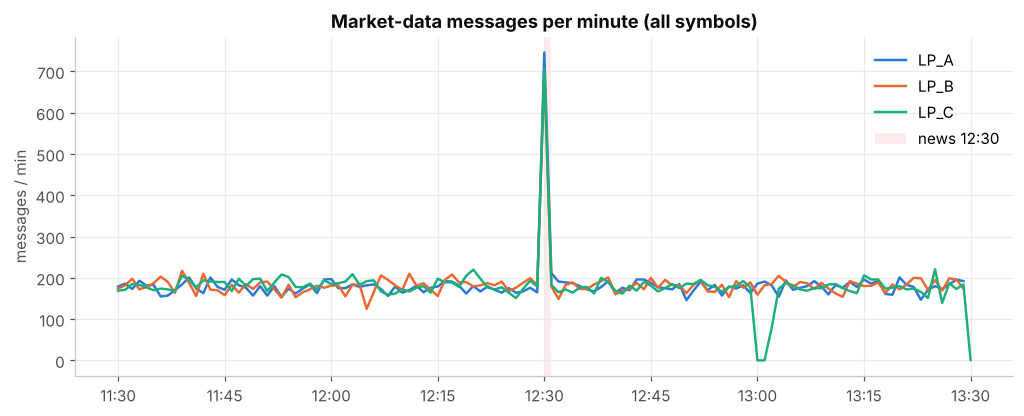

In [3]:
per_min = quotes.set_index("recv_time").groupby("lp").resample("1min").size().unstack(0)
fig, ax = plt.subplots()
for lp in per_min:
    ax.plot(per_min.index, per_min[lp], color=P.LP_COLORS[lp], label=lp)
P.shade(ax, "2025-10-15 12:30", "2025-10-15 12:31", "news 12:30")
ax.set_title("Market-data messages per minute (all symbols)"); ax.set_ylabel("messages / min")
P.time_axis(ax); ax.legend(); plt.show()

**Reading the chart:** steady lines all session, with a **spike at 12:30** (news: the market moves fast, so LPs
send many more updates) and a **drop to zero for LP_C at 13:00** (the outage). LP_B's gold freeze doesn't show
here because LP_B's other two symbols kept going; you only see it when you look per symbol.

---
## 2. Spreads by LP

Spread = ask − bid, in pips. A tighter (smaller) spread is cheaper for clients and makes the broker's prices more
competitive. LPs are often compared on spread first.

🔧 **The code below** shows each LP's spread per symbol: average (`mean`), median (`50%`, typical), 95th percentile
(`95%`, a wide moment) and maximum.

In [4]:
spreads = quotes.groupby(["symbol", "lp"]).spread_pips.describe(percentiles=[.5, .95])[["mean", "50%", "95%", "max"]].round(2)
spreads.unstack("lp")

mean              50%             95%             max            
lp      LP_A  LP_B  LP_C LP_A LP_B LP_C  LP_A LP_B LP_C  LP_A  LP_B  LP_C
symbol                                                                   
EURUSD  0.45  0.56  0.34  0.4  0.5  0.3  0.50  0.6  0.4   2.6   3.4   2.0
GBPUSD  0.79  0.90  0.67  0.7  0.8  0.6  0.90  1.0  0.7   4.8   5.3   3.9
XAUUSD  2.49  2.83  2.14  2.3  2.6  2.0  2.78  3.0  2.3  14.8  15.9  12.5

**Typical (median) spreads, in pips:**

| Symbol | LP_A | LP_B | LP_C |
|---|---|---|---|
| EURUSD | 0.4 | 0.5 | **0.3** |
| GBPUSD | 0.7 | 0.8 | **0.6** |
| XAUUSD (gold) | 2.3 | 2.6 | **2.0** |

**LP_C has the tightest spread on every symbol**, LP_A is close behind and LP_B is the widest. On paper LP_C is the
best LP. But a price is only worth something if the LP actually fills your orders at it. Lesson 05 shows that LP_C
rejects many orders, and what its "cheap" price really costs.

🔧 **The code below** draws the EURUSD spread of each LP over the session (median of every 30 seconds).

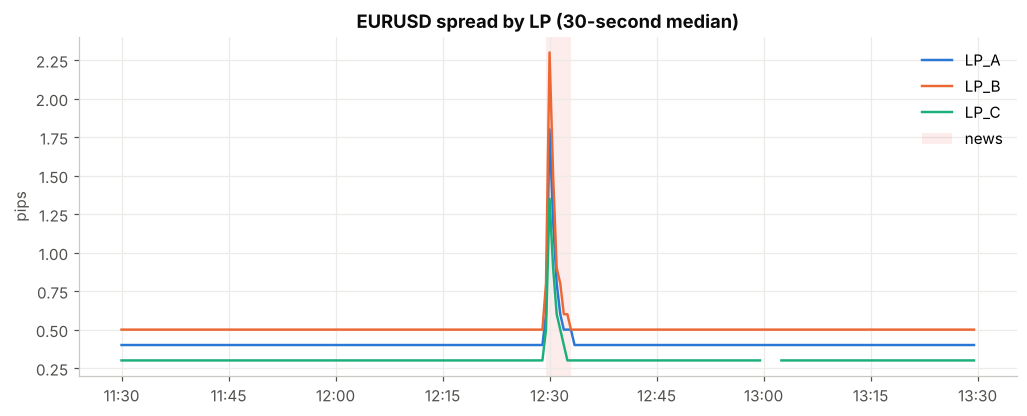

In [5]:
fig, ax = plt.subplots()
e = quotes[(quotes.symbol == "EURUSD")]
for lp, g in e.groupby("lp"):
    s = g.set_index("recv_time").spread_pips.resample("30s").median()
    ax.plot(s.index, s.values, color=P.LP_COLORS[lp], label=lp)
P.shade(ax, "2025-10-15 12:29:30", "2025-10-15 12:33", "news")
ax.set_title("EURUSD spread by LP (30-second median)"); ax.set_ylabel("pips"); P.time_axis(ax); ax.legend(); plt.show()

**Reading the chart:** flat and stable for all three LPs, except at the 12:30 news, where every LP widens its spread
at the same time (LPs protect themselves when the market is moving fast and they're unsure of the fair price).

---
## 3. Build the aggregated book

**The method, in words:**
1. Put all of one symbol's quotes on a single timeline, with one column per LP.
2. At every moment, each LP's price = its **latest** quote (if LP_A last updated 0.3 s ago, we still use that quote).
   This is called "forward-filling".
3. Best bid = the **highest** of the three bids; best ask = the **lowest** of the three asks.
4. Also record **which LP** gave the best bid (`bid_lp`) and the best ask (`ask_lp`).

🔧 **The code below** does those 4 steps for EURUSD and shows the last 5 moments of the session.

In [6]:
q = quotes[quotes.symbol == "EURUSD"]
wide_bid = q.pivot_table(index="recv_time", columns="lp", values="bid1", aggfunc="last").ffill()
wide_ask = q.pivot_table(index="recv_time", columns="lp", values="ask1", aggfunc="last").ffill()
manual = pd.DataFrame({"best_bid": wide_bid.max(axis=1), "best_ask": wide_ask.min(axis=1),
                       "bid_lp": wide_bid.idxmax(axis=1), "ask_lp": wide_ask.idxmin(axis=1)})
manual["spread_pips"] = (manual.best_ask - manual.best_bid) / PIP["EURUSD"]
manual.tail()

,best_bid,best_ask,bid_lp,ask_lp,spread_pips
recv_time,,,,,
2025-10-15 13:29:58.932,1.16536,1.16540,LP_A,LP_B,0.4
2025-10-15 13:29:58.991,1.16536,1.16540,LP_A,LP_B,0.4
2025-10-15 13:29:59.099,1.16536,1.16540,LP_A,LP_B,0.4
2025-10-15 13:29:59.477,1.16536,1.16539,LP_C,LP_A,0.3
2025-10-15 13:29:59.722,1.16535,1.16537,LP_A,LP_C,0.2


**Reading the output:** for example at 13:29:59.722, the best bid is 1.16535 from **LP_A** and the best ask is
1.16537 from **LP_C**: the client sees 1.16535 / 1.16537, a **0.2 pip** spread, made of two different LPs.

### Check our rebuild against what the clients actually saw
How do we know our rebuild is right? We compare it with the prices the platform really sent to clients. The **RAW**
group gets the LP price with **no markup**, so its prices should be exactly our best bid and best ask.

🔧 **The code below** loads the prices streamed to RAW clients for EURUSD, lines them up with our rebuilt book at the
same timestamps, and counts how often they're identical. It skips 13:00:22–13:02:32, when the platform had
already removed LP_C after the disconnect (Lesson 04 handles that properly).

In [7]:
cq = A.load_client_quotes()
raw = cq[(cq.symbol == "EURUSD") & (cq.group == "RAW")].set_index("time")
cmp = raw[["bid", "ask"]].join(manual[["best_bid", "best_ask"]], how="inner")
cmp = cmp[~cmp.index.to_series().between("2025-10-15 13:00:22", "2025-10-15 13:02:32")]
print(f"rows compared: {len(cmp):,} | bid matches: {np.isclose(cmp.bid, cmp.best_bid).mean():.1%} | "
      f"ask matches: {np.isclose(cmp.ask, cmp.best_ask).mean():.1%}")

rows compared: 21,608 | bid matches: 100.0% | ask matches: 100.0%


**21,608 moments compared, 100% match** on both bid and ask. Our rebuild is exactly what the bridge did.

**Why this matters in real life:** when a client complains *"you filled me at a price that never existed"*, this
is how you answer. You rebuild the book at that exact millisecond from the LP feeds and show which LP was offering
that price. Without being able to do this, you can't defend (or correct) a price.

---
## 4. Who sets the price? Share of time at the top of the book

Which LP gives our clients their price most of the time? We count **time**, not number of updates: an LP that is
best for 10 seconds matters more than one that is best for 10 milliseconds.

🔧 **The code below** builds the aggregated book for each symbol and calculates, for each LP, the **percentage of the
session** it was the best bid and the best ask.

In [8]:
def time_share(book, col):
    dur = book.index.to_series().diff().shift(-1).dt.total_seconds().fillna(0)
    return (dur.groupby(book[col]).sum() / dur.sum() * 100).round(1)

rows = []
for s in sym.index:
    b = A.aggregated_book(quotes, s)
    rows.append(pd.concat({"best bid %": time_share(b, "bid_lp"), "best ask %": time_share(b, "ask_lp")}, axis=1)
                .assign(symbol=s))
pd.concat(rows).reset_index(names="lp").pivot(index="lp", columns="symbol")

best bid %               best ask %              
symbol     EURUSD GBPUSD XAUUSD     EURUSD GBPUSD XAUUSD
lp                                                      
LP_A         47.9   45.0   34.0       46.9   47.8   32.9
LP_B          7.7   10.7   13.8        6.6   10.4   16.4
LP_C         44.4   44.2   52.2       46.5   41.8   50.6

**Reading the table** (% of the session each LP was the best price):
* **LP_A and LP_C share the top** of the book, each about 45% of the time for EURUSD and GBPUSD. On gold, LP_C is
  best about **half** the time.
* **LP_B** is rarely best (7–16%): its spreads are the widest, so it rarely wins.

**Why it matters:** the LP that is best most often attracts most of the client orders. If that LP then **rejects**
many of them (Lesson 05 shows LP_C does), lots of orders have to be re-sent elsewhere at worse prices. Being "best"
on the screen is only good if the LP also fills.

---
## 5. Aggregated spread vs single-LP spreads

Aggregation should give a spread **as tight as or tighter than** any single LP, because the best bid and best ask
can come from different LPs.

🔧 **The code below** compares, per symbol, the median aggregated spread with each LP's own median spread, and
measures the % of time the book was **crossed** (best bid > best ask, so the spread is negative) and **locked**
(best bid = best ask, spread zero).

In [9]:
agg_rows = []
for s in sym.index:
    b = A.aggregated_book(quotes, s)
    sp = (b.best_ask - b.best_bid) / PIP[s]
    agg_rows.append(dict(symbol=s, aggregated_median=sp.median(),
                         **{f"{lp}_median": quotes[(quotes.symbol == s) & (quotes.lp == lp)].spread_pips.median() for lp in A.LPS},
                         pct_time_crossed=100 * (sp < 0).mean(), pct_time_locked=100 * (sp == 0).mean()))
pd.DataFrame(agg_rows).set_index("symbol").round(2)

,aggregated_median,LP_A_median,LP_B_median,LP_C_median,pct_time_crossed,pct_time_locked
symbol,,,,,,
EURUSD,0.3,0.4,0.5,0.3,0.89,0.63
GBPUSD,0.6,0.7,0.8,0.6,0.27,0.03
XAUUSD,1.7,2.3,2.6,2.0,2.63,0.19


**Reading the table:**
* EURUSD aggregated 0.3 pips (same as the best single LP, LP_C); GBPUSD 0.6 (same as LP_C); **gold 1.7**, tighter
  than every single LP (best single is LP_C at 2.0). Aggregation works.
* But the book was **crossed** 0.89% of the time on EURUSD, 0.27% on GBPUSD and **2.63% on gold**.

**Why a crossed book is a red flag:** if one LP will buy at 1.16260 and another will sell at 1.16255, anyone could
buy from the second and sell to the first for a risk-free profit. Real LPs never allow that for more than an
instant. So when **our** book is crossed for long, it almost always means **one LP's price is wrong or old**, and
clients are being shown a price that doesn't really exist.

Where does it happen?

🔧 **The code below** counts, for each symbol and each minute, how many book updates were crossed, and draws it.
The shaded windows are the two incidents we suspect: LP_B's gold freeze (S02, around 12:05) and the LP_C outage
(S06, 13:00–13:02:30).

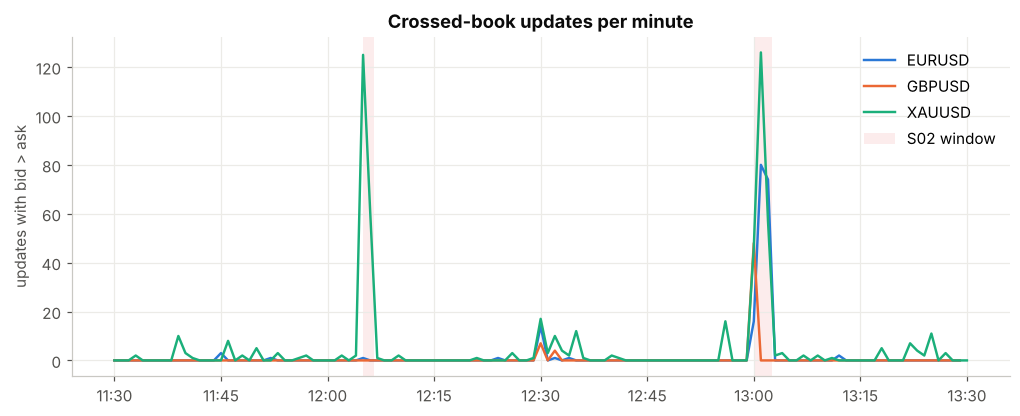

In [10]:
fig, ax = plt.subplots()
for i, s in enumerate(sym.index):
    b = A.aggregated_book(quotes, s)
    crossed = (b.best_bid > b.best_ask).astype(int)
    c = crossed.resample("1min").sum()
    ax.plot(c.index, c.values, color=P.SERIES[i], label=s)
P.shade(ax, "2025-10-15 12:05", "2025-10-15 12:06:30", "S02 window")
P.shade(ax, "2025-10-15 13:00", "2025-10-15 13:02:30")
ax.set_title("Crossed-book updates per minute"); ax.set_ylabel("updates with bid > ask")
P.time_axis(ax); ax.legend(); plt.show()

**Reading the chart:** crossed books are almost entirely in **two windows**:
* **12:05–12:06, gold only**: LP_B's gold price was frozen (stale) while the real market rallied. LP_B's old, low
  ask stayed in the book below the other LPs' rising bids → crossed.
* **13:00–13:02, all symbols**: LP_C's connection was dead, but its last prices stayed in the book (until the
  Logout at 13:00:22) while the market moved on.

(There's also a small blip at 12:30: at the news, prices jumped and the LPs updated a few hundred milliseconds
apart, so for an instant one LP's old price crossed another's new one. That's brief and expected.)

Both big windows are the same kind of problem: **an old price kept in the book as if it were live.** Lesson 04 measures how old
each price is and builds the filters that would have removed them.

---
## 6. Depth: how much size is available at the top?

The price is only half the story: **how much** can you trade at it? If the best ask has 500,000 EUR available and a
client wants 2,000,000, only part can be filled at that price; the rest goes to worse prices or other LPs
(partial fills, Lesson 01 section 9).

🔧 **The code below** calculates the average level-1 ask size per minute for each symbol, and draws it relative to
its normal value (1 = normal size, 0.5 = half the normal size).

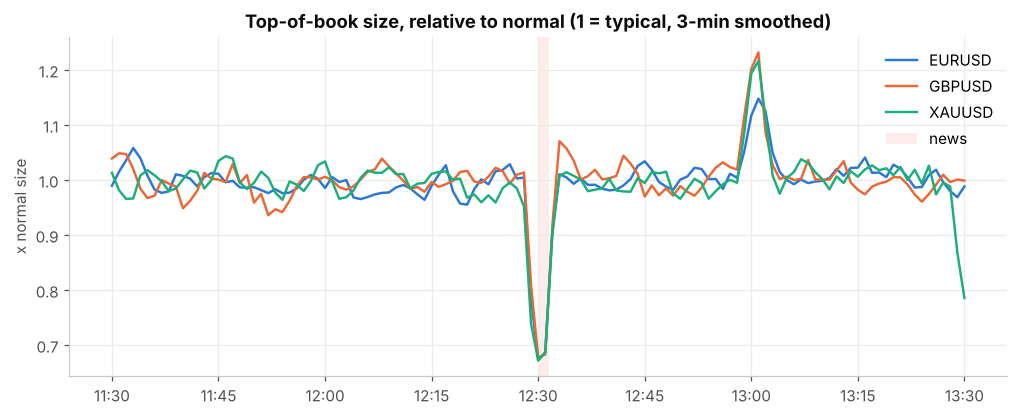

In [11]:
depth = (quotes.set_index("recv_time").groupby("symbol").asize1.resample("1min").mean().unstack(0)
         .rolling(3, center=True, min_periods=1).mean())                        # smooth the 1-minute averages
fig, ax = plt.subplots()
for i, s in enumerate(depth):
    ax.plot(depth.index, depth[s] / depth[s].median(), color=P.SERIES[i], label=s)
P.shade(ax, "2025-10-15 12:30", "2025-10-15 12:31:30", "news")
ax.set_title("Top-of-book size, relative to normal (1 = typical, 3-min smoothed)"); ax.set_ylabel("x normal size")
P.time_axis(ax); ax.legend(); plt.show()

**Reading the chart:** around 1 all session, with a clear **dip at the 12:30 news** on all three symbols (down to
~0.7). When the market is uncertain, LPs not only widen their spreads, they also **offer less size**.

There's also a **bump up around 13:00**. That is not extra liquidity: the line is an average over all LP price
updates, and LP_C (which offers the smallest sizes) stopped sending at 13:00. For those minutes the average is made
only of LP_A's and LP_B's bigger sizes. A good reminder to always ask *"which inputs are in this average right now?"*

---
## 7. News event deep-dive (incident S03, 12:30:00)

Economic news (like US inflation or jobs figures) is released at a fixed time and can move prices a lot in seconds.
Let's measure exactly what happened to our prices.

🔧 **The code below** compares two windows for each symbol: the **5 calm minutes before** (12:24–12:29) and the
**first minute after** the news (12:30–12:31). For each: updates per second (all LPs together), median spread in
pips, and median level-1 size.

In [12]:
def window_stats(t0, t1, label):
    w = quotes[(quotes.recv_time >= t0) & (quotes.recv_time < t1)]
    secs = (pd.Timestamp(t1) - pd.Timestamp(t0)).total_seconds()
    return (w.groupby("symbol").agg(updates_per_s=("seq", lambda s: len(s) / secs), median_spread_pips=("spread_pips", "median"),
                                    median_l1_size=("asize1", "median")).assign(window=label))

news = pd.concat([window_stats("2025-10-15 12:24:00", "2025-10-15 12:29:00", "1) before 12:24-12:29"),
                  window_stats("2025-10-15 12:30:00", "2025-10-15 12:31:00", "2) after 12:30-12:31")])
news.reset_index().pivot(index="symbol", columns="window").round(2)

updates_per_s                         median_spread_pips                             median_l1_size                     
window 1) before 12:24-12:29 2) after 12:30-12:31 1) before 12:24-12:29 2) after 12:30-12:31 1) before 12:24-12:29 2) after 12:30-12:31
symbol                                                                                                                                 
EURUSD                  2.86                12.08                   0.4                  1.4             1500000.0             525000.0
GBPUSD                  2.85                11.72                   0.7                  2.5             3000000.0            1050000.0
XAUUSD                  3.04                11.93                   2.2                  8.1                 200.0                105.0

**Before vs after the news:**

| | EURUSD | GBPUSD | Gold |
|---|---|---|---|
| Updates per second | 2.9 → **12.1** (×4) | 2.9 → **11.7** | 3.0 → **11.9** |
| Median spread (pips) | 0.4 → **1.4** (×3.5) | 0.7 → **2.5** | 2.2 → **8.1** |
| Median level-1 size | 1,500,000 → **525,000** (−65%) | 3,000,000 → **1,050,000** | 200 oz → **105 oz** |

In plain words: **4 times more price messages, spreads 3–4 times wider, and about a third of the usual size.**

🔧 **The code below** draws the aggregated best bid and best ask for EURUSD from 12:29 to 12:33.

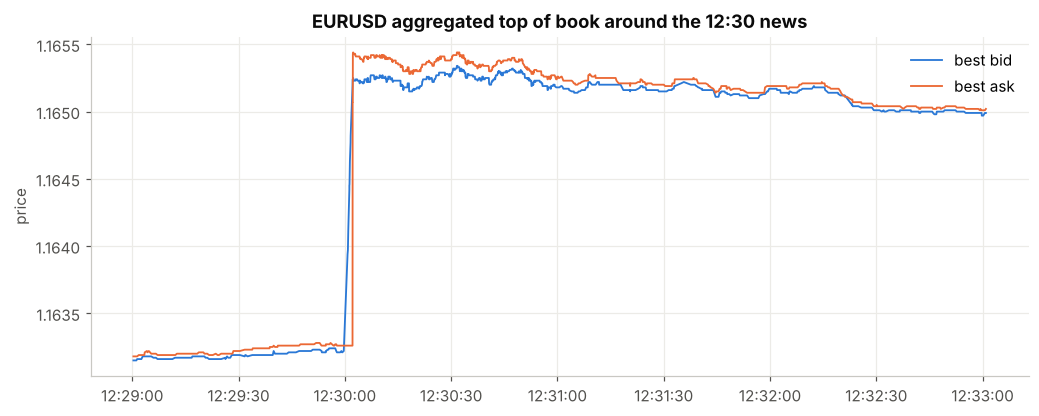

In [13]:
b = A.aggregated_book(quotes, "EURUSD")
w = b.loc["2025-10-15 12:29:00":"2025-10-15 12:33:00"]
fig, ax = plt.subplots()
ax.plot(w.index, w.best_bid, color=P.SERIES[0], lw=1.2, label="best bid")
ax.plot(w.index, w.best_ask, color=P.SERIES[1], lw=1.2, label="best ask")
ax.set_title("EURUSD aggregated top of book around the 12:30 news"); ax.set_ylabel("price")
P.time_axis(ax, "%H:%M:%S"); ax.legend(); plt.show()

**Reading the chart:** a quiet line, then at 12:30:00 the price **jumps about 20 pips in two seconds**, and the gap
between the two lines (the spread) opens up before slowly narrowing again.

**What news means for the broker:**
* **Clients' orders slip more**: the price moves between the click and the fill, and there's less size, so more
  partial fills (Lessons 05 and 06).
* **The bridge has 4 times more messages to process**, so it can fall behind and add delay (Lesson 06 measures
  this).
* **B-book risk:** if the broker holds the other side of clients' positions (B-book), a 20-pip jump can turn into a
  sudden loss.
* **Usual controls on a dealing desk:** before scheduled news, widen markups or set a minimum spread, lower the
  maximum order size, warn the support team, and move risky clients to A-book (pass their trades to LPs).

**Next:** Lesson 04, feed quality: old (stale) prices, wrong prices (bad ticks), crossed books, and the filters that
stop them.